<a href="https://colab.research.google.com/github/Tamondong-Ivan-Rex-B/CPE-031-Visualization-and-Data-Analysis/blob/CPE-031_TAMONDONG/Tamondong%2C_Ivan_Rex_B__Hands_On_Activity_9___Exploring_Data_Visually.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Exploring Data Visually**





---



**Discussions:**

Exploratory Data Analysis (EDA) is the process of analyzing datasets to summarize their main characteristics and gain insights before formal modeling. Visual exploration helps identify trends, relationships, and data quality issues.

Key Components:

Univariate Analysis:
Analyzing one variable at a time (e.g., histograms, bar charts).

Bivariate Analysis:
Exploring relationships between two variables (e.g., scatterplots, crosstabs).

Missing Data Analysis:
Identifying and handling missing or null values.

Time-Series Visualization:
Displaying data across time to reveal trends or seasonality.

Geospatial Visualization:
Mapping data to geographical regions to identify spatial patterns.

EDA is both an art and science combining statistical summaries with visual intuition.

**Procedures:**

**Color and Perception**

Section 1: Organizing and Exploring Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample dataset
data = {
    "Product": ["Juice", "Smoothie", "Juice", "Smoothie", "Juice", "Smoothie"],
    "Region": ["North", "South", "East", "West", "North", "East"],
    "Sales": [120, 150, 90, 110, 130, 170],
    "Profit": [30, 45, 20, 25, 35, 50]
}
df = pd.DataFrame(data)

# Display the dataset
df

,Product,Region,Sales,Profit
0,Juice,North,120,30
1,Smoothie,South,150,45
2,Juice,East,90,20
3,Smoothie,West,110,25
4,Juice,North,130,35
5,Smoothie,East,170,50


Task 1: Analyzing Variables One at a Time

/tmp/ipython-input-2975764973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Region", data=df, palette="Set2")


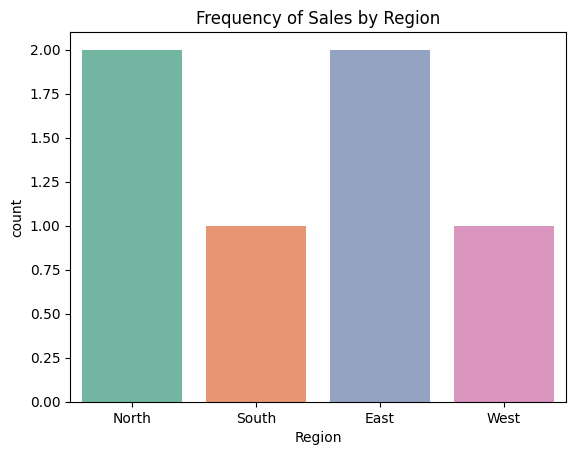

In [ ]:
#Categorical Variable
# Countplot for categorical variable
sns.countplot(x="Region", data=df, palette="Set2")
plt.title("Frequency of Sales by Region")
plt.show()


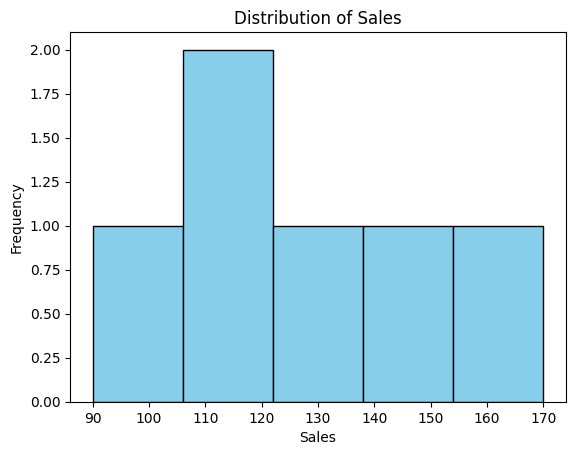

In [ ]:
#Quantitative Variable
# Histogram for quantitative variable
plt.hist(df["Sales"], bins=5, color="skyblue", edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

Task: <br>
Create one countplot for Product and one histogram for Profit. <br>
Compare their patterns and interpret what they mean.

/tmp/ipython-input-1643778404.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Product", data=df, palette="viridis")


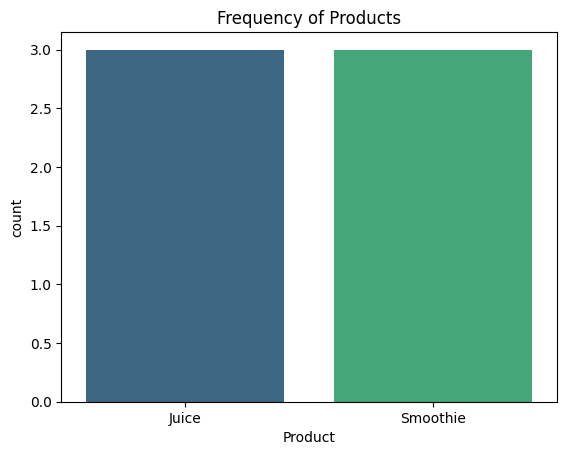

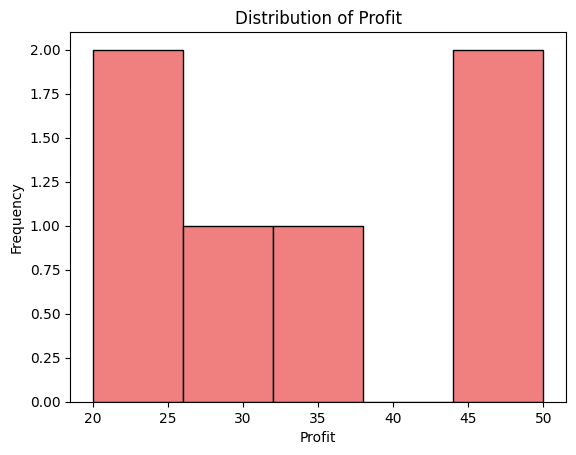

In [43]:
#Code here
# Countplot for 'Product'
sns.countplot(x="Product", data=df, palette="viridis")
plt.title("Frequency of Products")
plt.show()

# Histogram for 'Profit'
plt.hist(df["Profit"], bins=5, color="lightcoral", edgecolor="black")
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

Interpretation:

a. Countplot for Product <br>
The countplot graph shows that both "Juice" and "Smoothie" products appear with equal frequency in the dataset, which is 3 times each. This means that there is a balanced representation of both product types in the data.

b. Histogram for Profit: <br>
The histogram for 'Profit' shows the distribution of profit values. With only 6 data points, it's difficult to see a clear pattern, but it appears that the profits are spread across a range, with a few instances in each bin. To get a better understanding of the profit distribution, a larger dataset would be beneficial.

Section 2: Relationships Between Variables

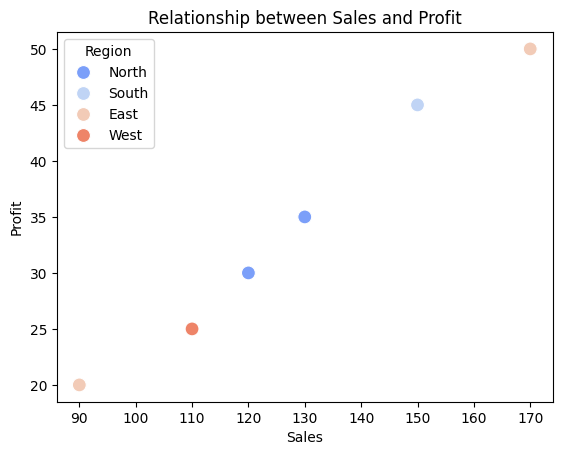

In [ ]:
# Scatterplot: Sales vs Profit
sns.scatterplot(x="Sales", y="Profit", hue="Region", data=df, palette="coolwarm", s=100)
plt.title("Relationship between Sales and Profit")
plt.show()

In [ ]:
# Crosstabulation example
pd.crosstab(df["Region"], df["Product"], values=df["Sales"], aggfunc="mean").fillna(0)


Product,Juice,Smoothie
Region,,
East,90.0,170.0
North,125.0,0.0
South,0.0,150.0
West,0.0,110.0


Task: <br>
Interpret whether higher sales also mean higher profit. <br>
Which region seems to perform best?

Interpret whether higher sales also mean higher profit. <br>
Based on the graph, it shows that the higher the sales, the higher the profit. In the scatter plot, we can see that there is a linear relationship between the sales and the profit of the products.

Which region seems to perform best?<br>
By looking at both Sales and Profit from the scatterplot, the points with the highest Sales and Profit is from the 'South' and 'East' regions. Also, if we consider total profit per region, 'South' has 45, 'East' has 20+50=70, 'North' has 30+35=65, and 'West' has 25. The East region appears to perform best with the highest total profit, which is 70, and lso a high mean sales value, which is 130.

Section 3: Analysis of Missing Data

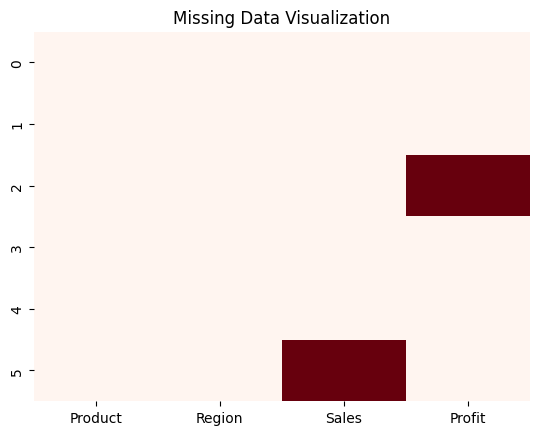

,0
Product,0
Region,0
Sales,1
Profit,1


In [ ]:
# Introduce missing data
df_missing = df.copy()
df_missing.loc[2, "Profit"] = np.nan
df_missing.loc[5, "Sales"] = np.nan

# Visualize missing data
sns.heatmap(df_missing.isnull(), cbar=False, cmap="Reds")
plt.title("Missing Data Visualization")
plt.show()

# Display missing summary
df_missing.isnull().sum()


Task: <br>
Describe what you observe in the missing data visualization. <br>
Which variables need attention before analysis?

Describe what you observe in the missing data visualization. <br>
The heatmap shows red cells where there are missing values. We can see red in the 'Profit' column for one row and in the 'Sales' column for another row. This visually shows the presence of missing data. Also, the output of df_missing.isnull().sum() shows us the number of missing values in each column, and it shows that both the 'Sales' and 'Profit' columns have 1 missing value each.

Which variables need attention before analysis?:<br>
 Both the 'Sales' and 'Profit' variables need attention before further analysis because of the missing values. We can either filling them in or exclude the rows with missing data.

Section 4: Visualizing Time-Series Data

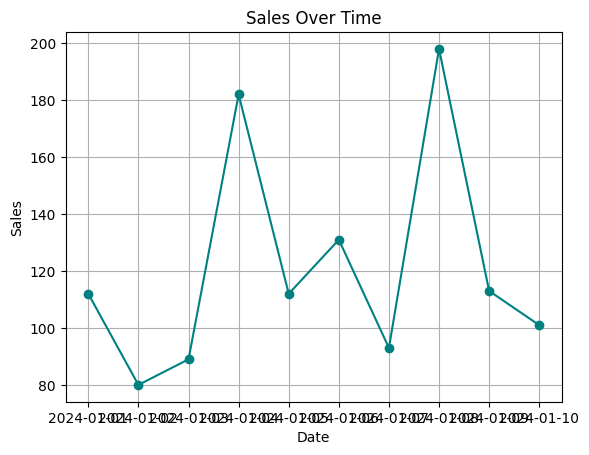

In [ ]:
# Generate time-series example
dates = pd.date_range(start="2024-01-01", periods=10)
sales = np.random.randint(80, 200, 10)
ts_df = pd.DataFrame({"Date": dates, "Sales": sales})

# Line chart for time-series
plt.plot(ts_df["Date"], ts_df["Sales"], marker="o", color="teal")
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Task: <br>
Add a moving average line (rolling mean) to smooth fluctuations. <br>
Hint: Use ts_df["Sales"].rolling(window=3).mean().

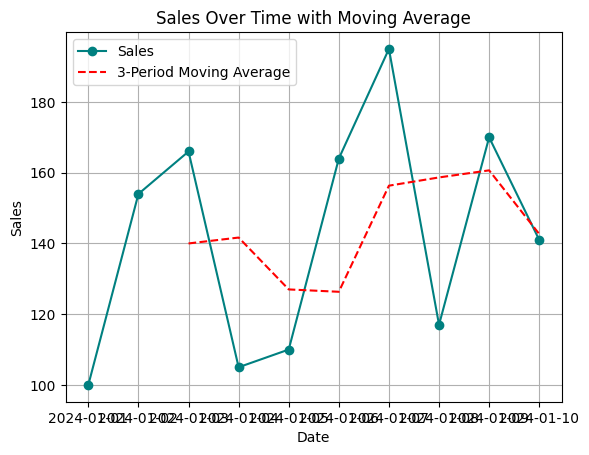

In [ ]:
# Generate time-series example
dates = pd.date_range(start="2024-01-01", periods=10)
sales = np.random.randint(80, 200, 10)
ts_df = pd.DataFrame({"Date": dates, "Sales": sales})

# Calculate the moving average
ts_df["Sales_MA"] = ts_df["Sales"].rolling(window=3).mean()

# Plot the original sales data
plt.plot(ts_df["Date"], ts_df["Sales"], marker="o", color="teal", label="Sales")

# Plot the moving average
plt.plot(ts_df["Date"], ts_df["Sales_MA"], color="red", linestyle="--", label="3-Period Moving Average")

plt.title("Sales Over Time with Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.legend()
plt.show()

Section 5: Visualizing Geospatial Data

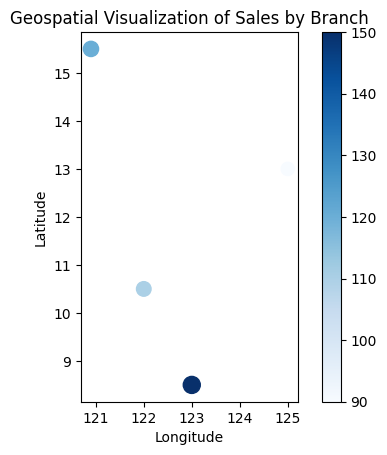

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

# Sample coordinates (latitude, longitude)
coords = {
    "Branch": ["North", "South", "East", "West"],
    "Latitude": [15.5, 8.5, 13.0, 10.5],
    "Longitude": [120.9, 123.0, 125.0, 122.0],
    "Sales": [120, 150, 90, 110]
}

geo_df = pd.DataFrame(coords)
geo_df["geometry"] = [Point(xy) for xy in zip(geo_df.Longitude, geo_df.Latitude)]
gdf = gpd.GeoDataFrame(geo_df, geometry="geometry")

# Plot simple map (Philippines outline optional if available)
gdf.plot(column="Sales", cmap="Blues", legend=True, markersize=geo_df["Sales"])
plt.title("Geospatial Visualization of Sales by Branch")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Task: <br>
Interpret which branch has the highest sales geographically. <br>
How can such visualization help in business decision-making?

Interpret which branch has the highest sales geographically: <br>
By looking at the size of the markers on the map, the South branch appears to have the highest sales. The North branch has the second highest sales, followed by the West, and then the East branch with the lowest sales.

How can such visualization can help in business decision-making: <br> Geospatial visualizations like this can be very helpful in business decision-making by providing a clear way to understand the spatial distribution of data. For example, we can quickly see which branches or regions are doing well in terms of sales and which ones may need more attent based on their performance.

**5. Supplementary Activity**

Create your own mini exploratory analysis:

1. Choose a dataset (e.g., from Kaggle, or a CSV file you have).

2. Perform:

*   Univariate analysis (1 categorical + 1 quantitative)
*   Bivariate analysis (scatterplot or crosstab)
*   Missing data visualization
*   Time-series or geospatial visualization (choose one)
3. Summarize your key insights using visual interpretation.

In [46]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = '/content/drive/Othercomputers/My Laptop/TIP QC/TIP/Computer Engineering/2ND YEAR/1ST SEMESTER/CPE 031 Visualizations and Data Analysis/Finals/exams.csv'
exams_df = pd.read_csv(file_path)
display(exams_df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68


/tmp/ipython-input-1216496294.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=exams_df, palette='viridis')


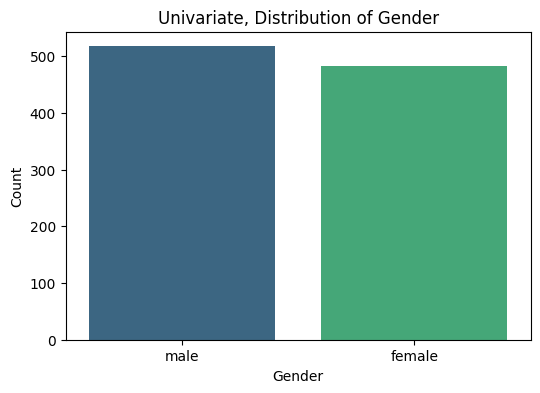

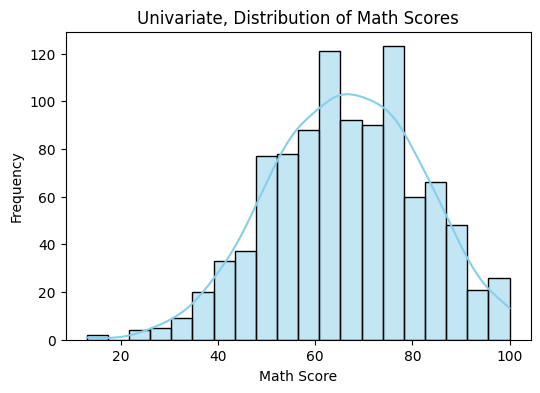

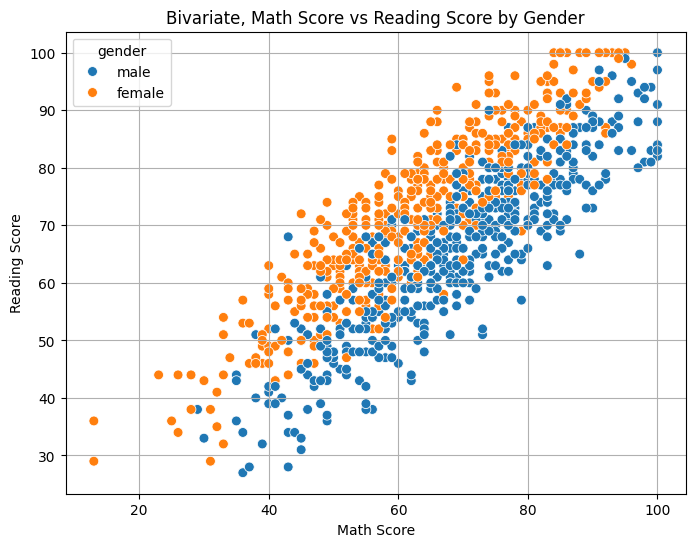

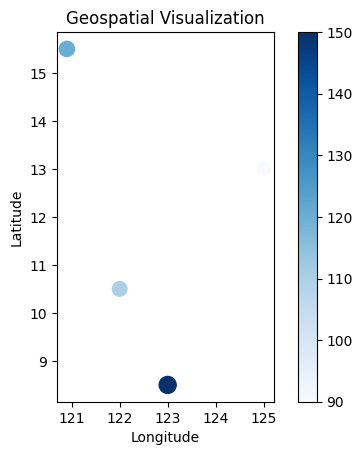

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns


# Univariate
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=exams_df, palette='viridis')
plt.title('Univariate, Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Univariate
plt.figure(figsize=(6, 4))
sns.histplot(data=exams_df, x='math score', bins=20, kde=True, color='skyblue')
plt.title('Univariate, Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()

# Bivariate
plt.figure(figsize=(8, 6))
sns.scatterplot(x='math score', y='reading score', hue='gender', data=exams_df, s=50)
plt.title('Bivariate, Math Score vs Reading Score by Gender')
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.grid(True)
plt.show()

import geopandas as gpd
from shapely.geometry import Point

# Geospatial Visualization
coords = {
    "Branch": ["North", "South", "East", "West"],
    "Latitude": [15.5, 8.5, 13.0, 10.5],
    "Longitude": [120.9, 123.0, 125.0, 122.0],
    "Sales": [120, 150, 90, 110]
}

geo_df = pd.DataFrame(coords)
geo_df["geometry"] = [Point(xy) for xy in zip(geo_df.Longitude, geo_df.Latitude)]
gdf = gpd.GeoDataFrame(geo_df, geometry="geometry")

gdf.plot(column="Sales", cmap="Blues", legend=True, markersize=geo_df["Sales"])
plt.title("Geospatial Visualization")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**6. Conclusion/Learnings/Analysis:**

In this activity, we created different kinds of graph using different types of categories. In the supplementary activity, in the univariate analysis, we used one quantitative and one qualitative data and this is used to understant the relationship and the distribution of a categorty and a data. For Bivariate, we used 2 qualitative and 2 quantitative and this is used to assess the relationship between pairs of data and other categories. Also, I applied the techniques from the procedure to the supplementary activity. These Analysis and Visualizations are important to be used in Exploratory Data Analysis of the csv file in the supplementary activity in order to help us identify the relationsips between the categories of the datas.